In [ ]:
import pandas as pd
import src.create_RFM as c
import src.data_preprocessing as dp
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
data=pd.read_csv('data.csv',encoding='latin-1')

In [27]:
data=dp.pipeline(data)

In [28]:
rfm=c.rfm_pipeline(data,True)

In [29]:
rfm.columns

Index(['R', 'F', 'M', 'R_score', 'F_score', 'M_score', 'RF_score', 'segments'], dtype='str')

In [30]:
rfml=rfm.drop('segments',axis=1)

In [31]:
rfm

,R,F,M,R_score,F_score,M_score,RF_score,segments
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,11,hibernating
12347.0,2,182,4310.00,5,5,5,55,champions
12348.0,75,31,1797.24,2,3,4,23,at_Risk
12349.0,19,73,1757.55,4,4,4,44,loyal_customers
12350.0,310,17,334.40,1,2,2,12,hibernating
...,...,...,...,...,...,...,...,...
18280.0,278,10,180.60,1,1,1,11,hibernating
18281.0,181,7,80.82,1,1,1,11,hibernating
18282.0,8,12,178.05,5,1,1,51,new_customers


C:\Users\COMPUMARTS\AppData\Local\Temp\ipykernel_8996\334839047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(rfm,x='segments', palette='crest', legend=True)


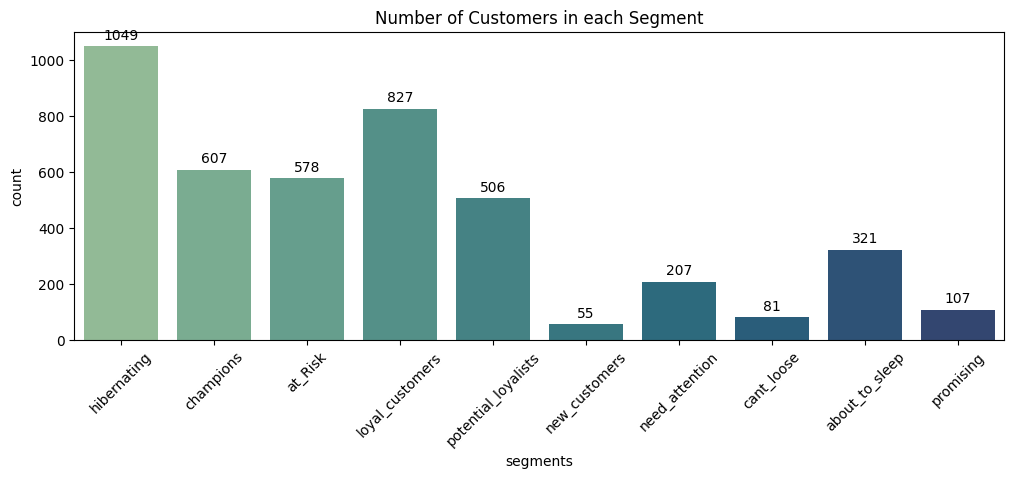

In [65]:
plt.figure(figsize=(12,4))
ax=sns.countplot(rfm,x='segments', palette='crest', legend=True)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xticks(rotation=45)
plt.title('Number of Customers in each Segment')
plt.show()

<Axes: ylabel='segments'>

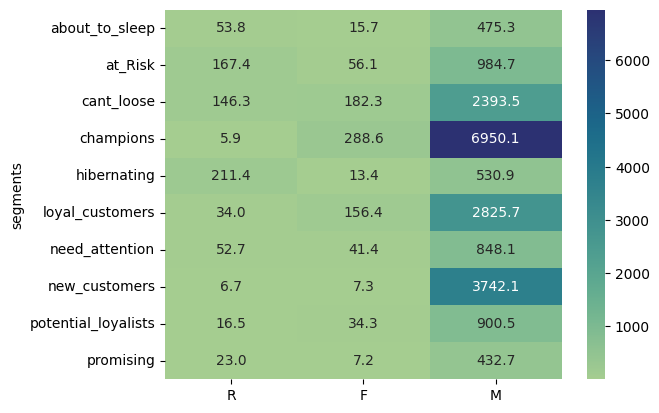

In [113]:
segment_metrics = rfm.groupby('segments')[['R','F','M']].mean()
sns.heatmap(segment_metrics, annot=True, fmt=".1f",cmap='crest')

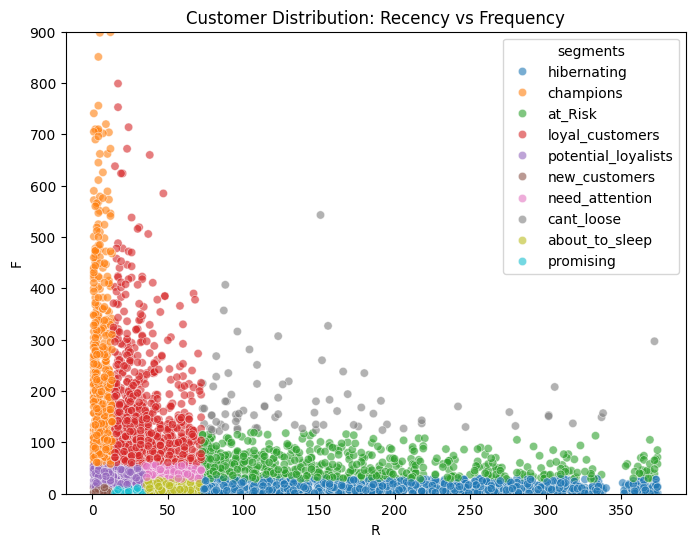

In [116]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm, x='R', y='F', hue='segments', alpha=0.6)
plt.title('Customer Distribution: Recency vs Frequency')
plt.ylim(0,900)
plt.show()

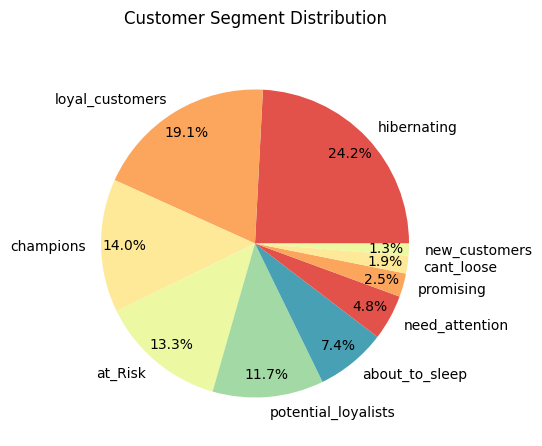

In [115]:
plt.figure(figsize=(5, 5))

data = rfm['segments'].value_counts()

plt.pie(data, 
        labels=data.index, 
        autopct='%1.1f%%', 
        pctdistance=0.85, 
        labeldistance=1.1,
        colors=sns.color_palette('Spectral'))

plt.title('Customer Segment Distribution', pad=20)
plt.show()